In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rackcostumera = pd.read_csv("rack_kunde_a_regal_og.csv")
rackcostumera['date'] = pd.to_datetime(rackcostumera['date'])

In [4]:
rackcostumera.columns

Index(['drum_id', 'tenant', 'rack', 'product', 'part_number', 'date',
       'days_elapsed', 'daily_min_cable_length_m', 'daily_max_cable_length_m',
       'daily_avg_cable_length_m', 'linear_forecast_m', 'forecast_error_m',
       'sensor_readings_count', 'avg_battery_voltage', 'avg_signal_strength',
       'initial_cable_length_m', 'order_threshold_m',
       'depletion_rate_m_per_day', 'r_squared'],
      dtype='str')

In [17]:
rackcostumera.depletion_rate_m_per_day

452     1.08
247     0.59
35      1.78
141     0.82
657     0.06
        ... 
2776    0.36
3242    3.71
2445    0.03
3449    0.34
3575    0.99
Name: depletion_rate_m_per_day, Length: 3576, dtype: float64

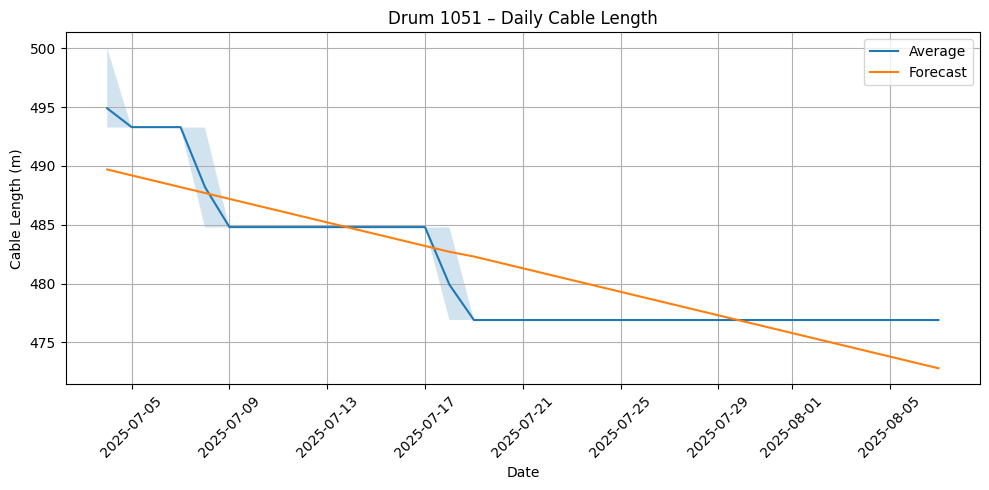

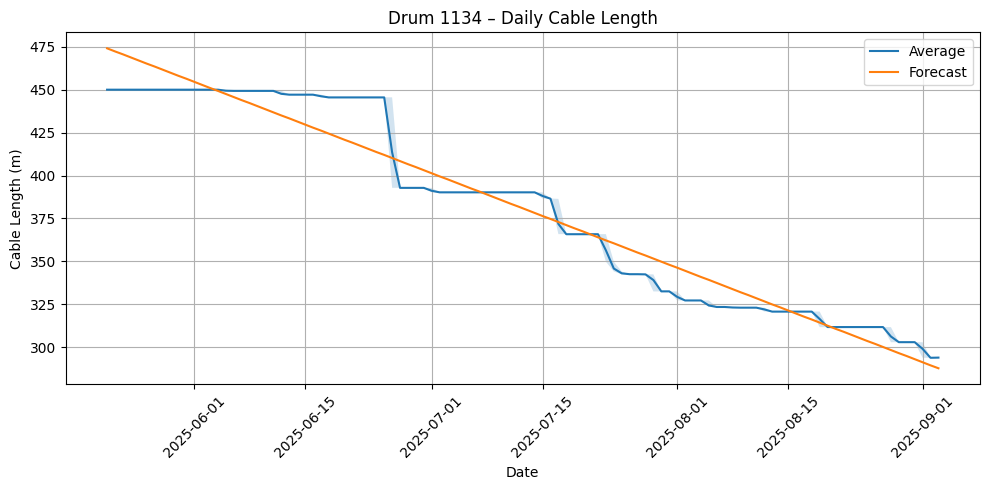

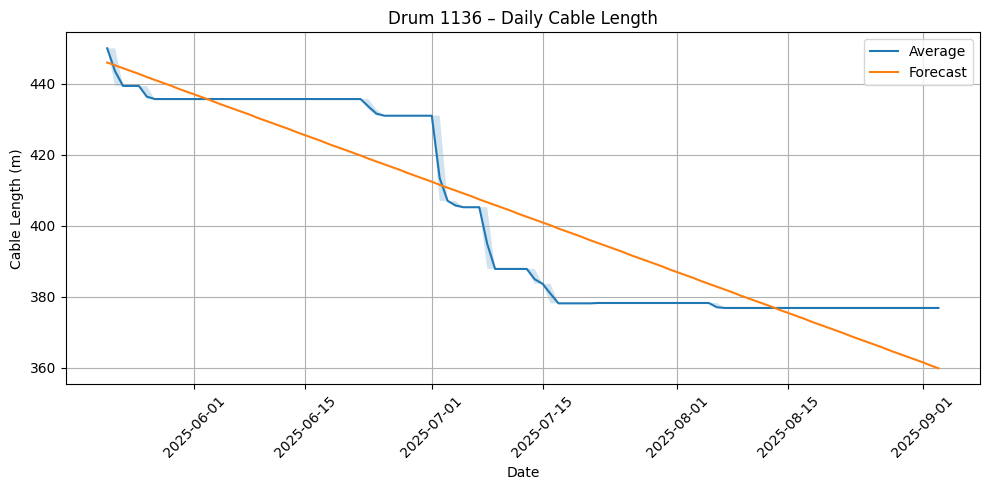

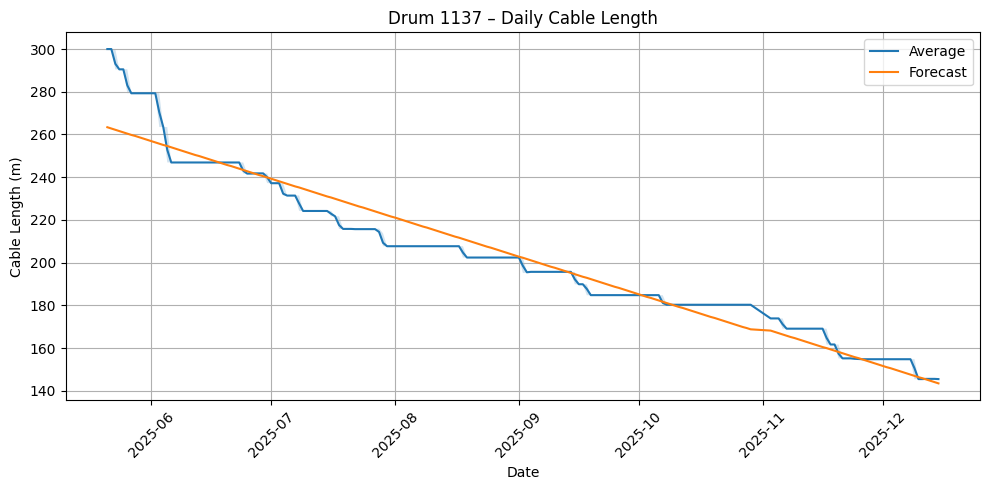

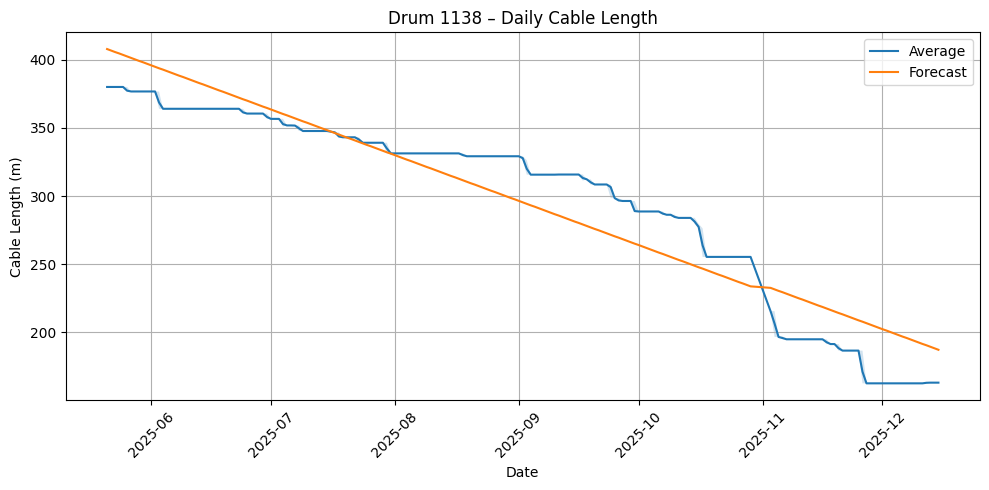

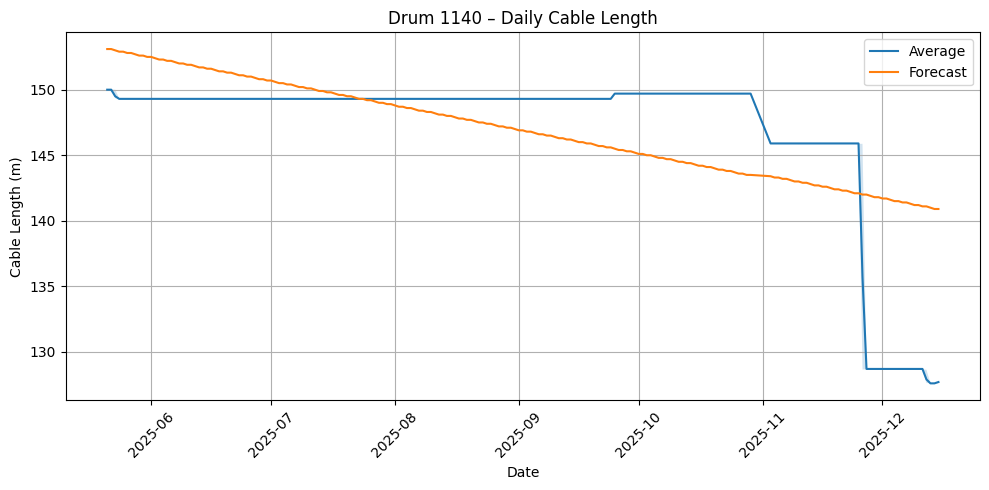

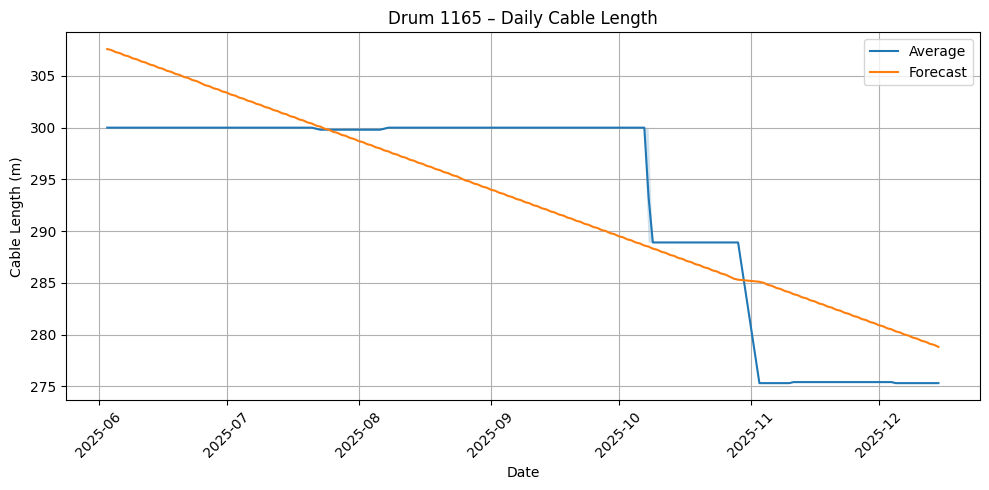

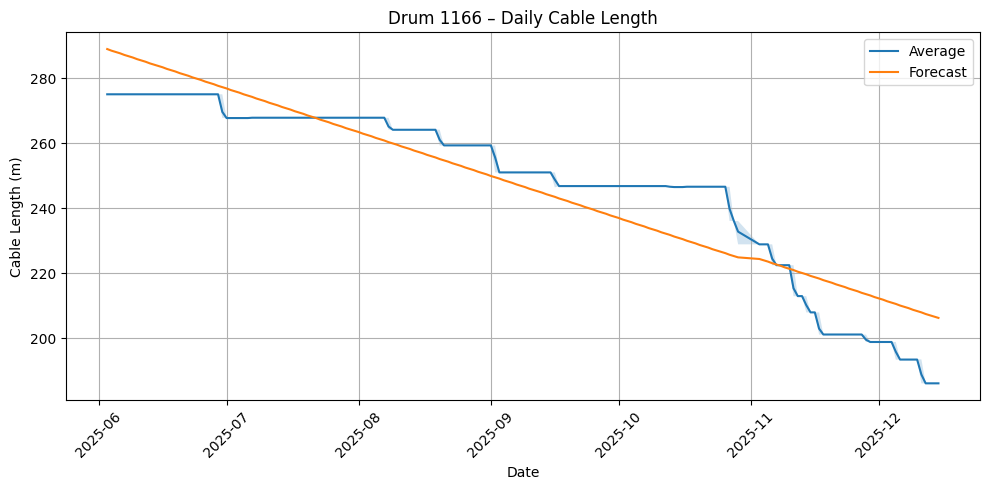

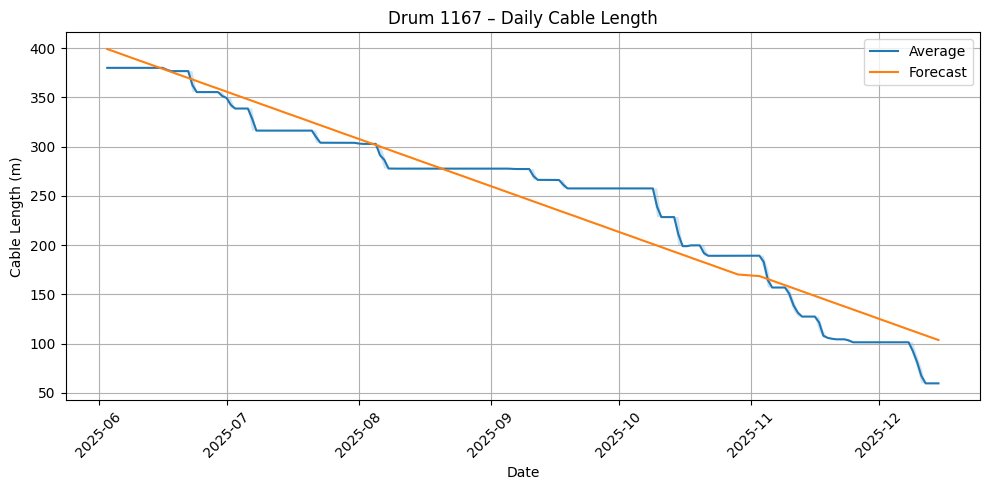

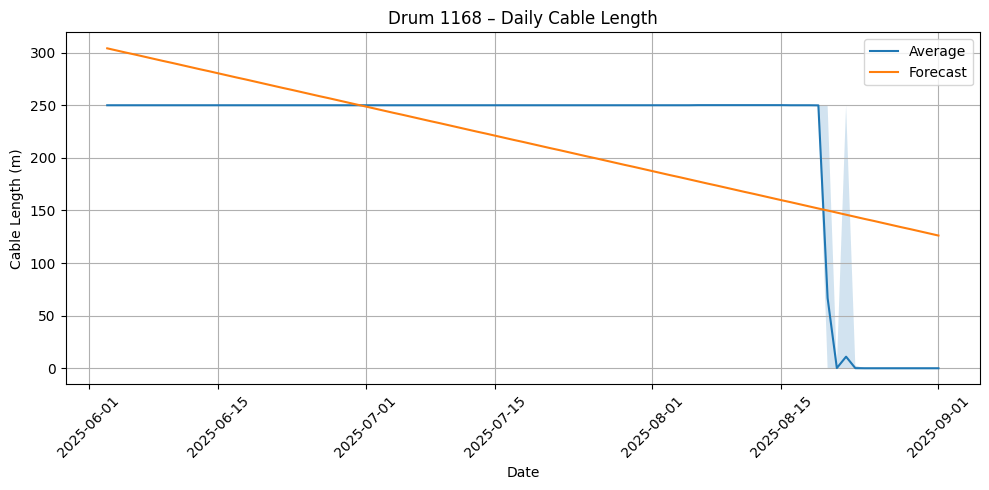

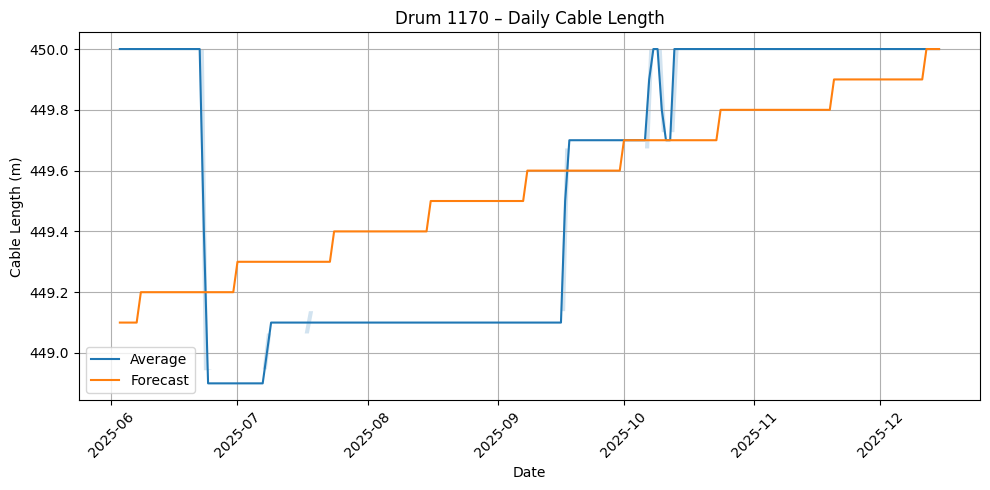

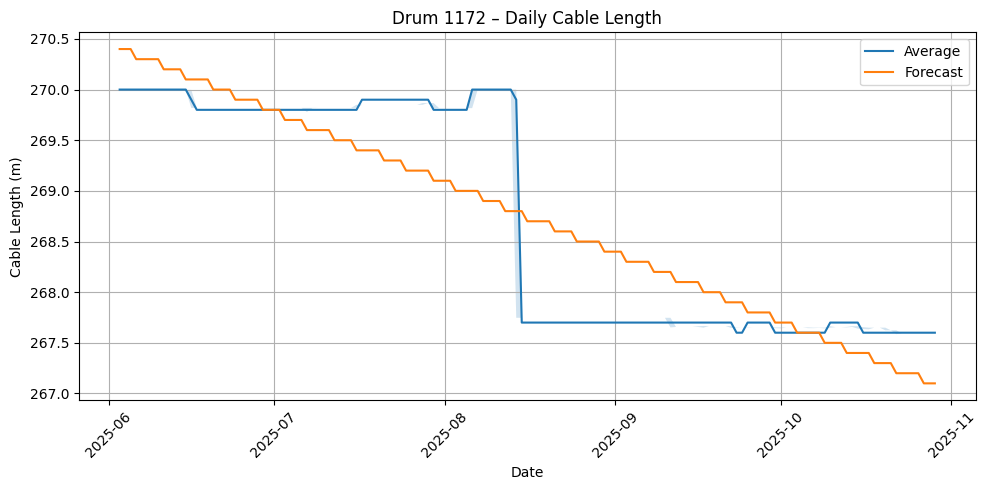

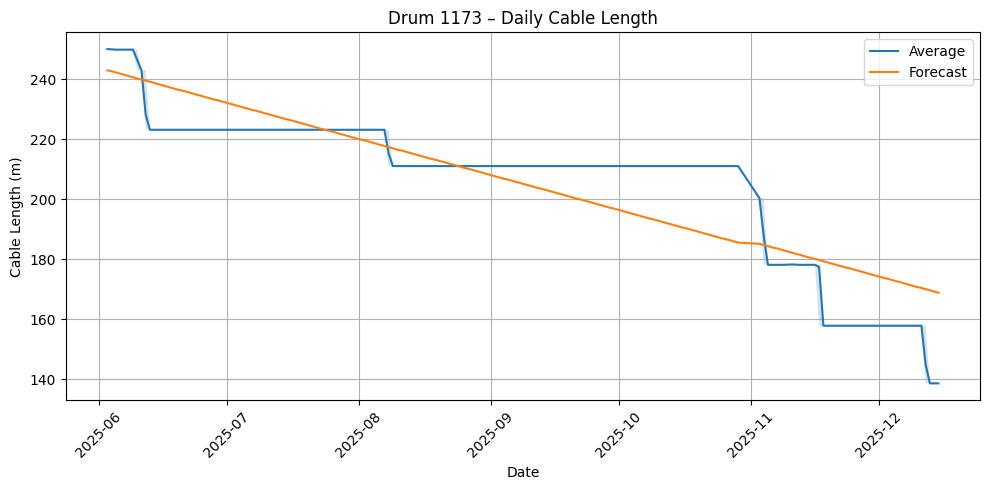

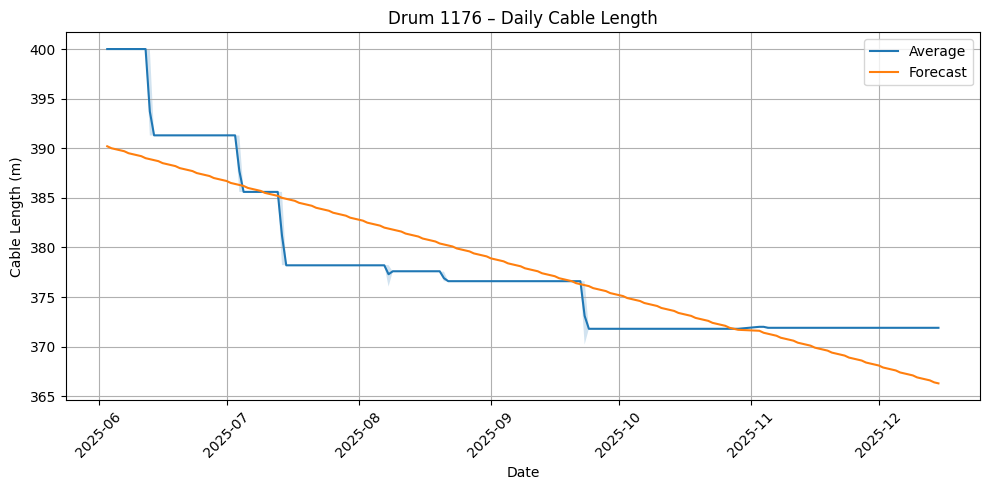

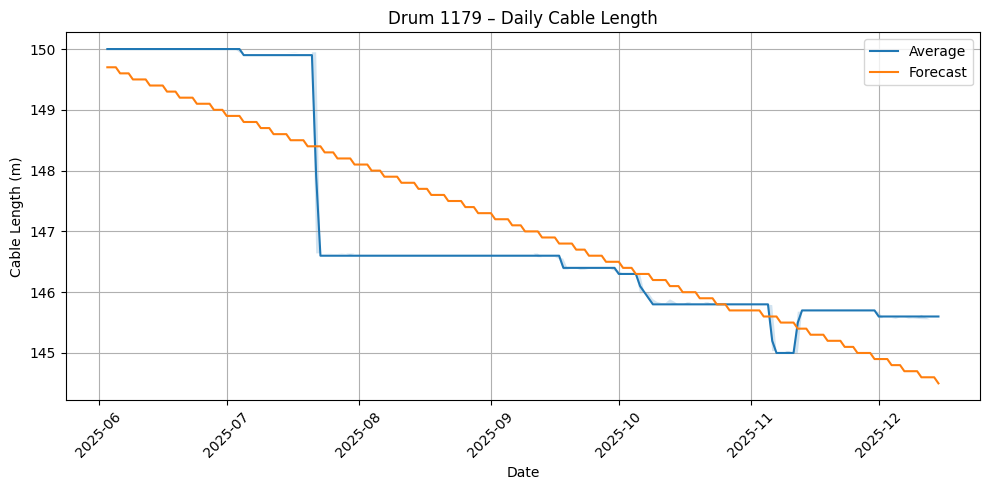

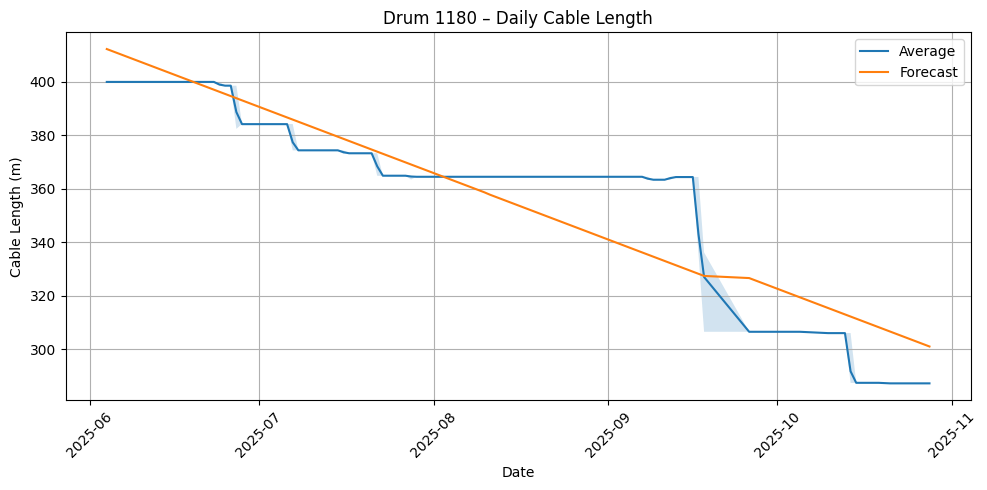

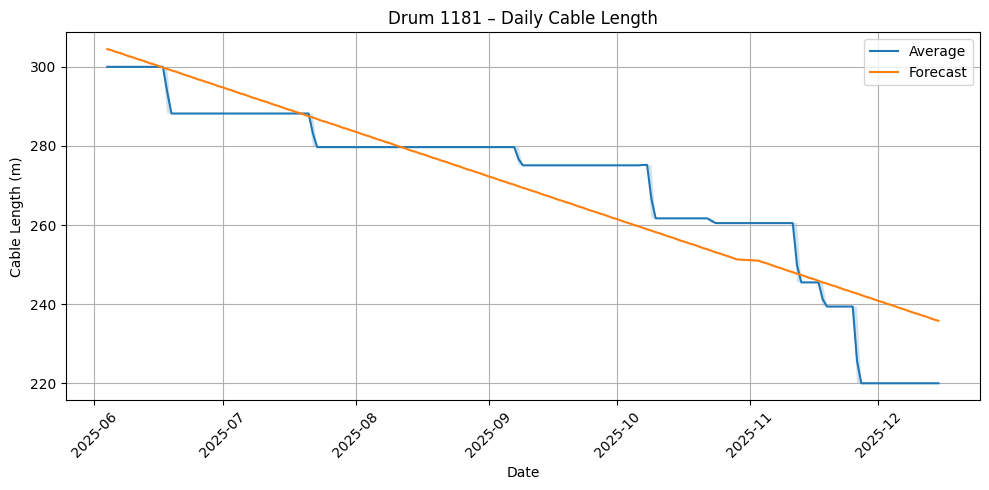

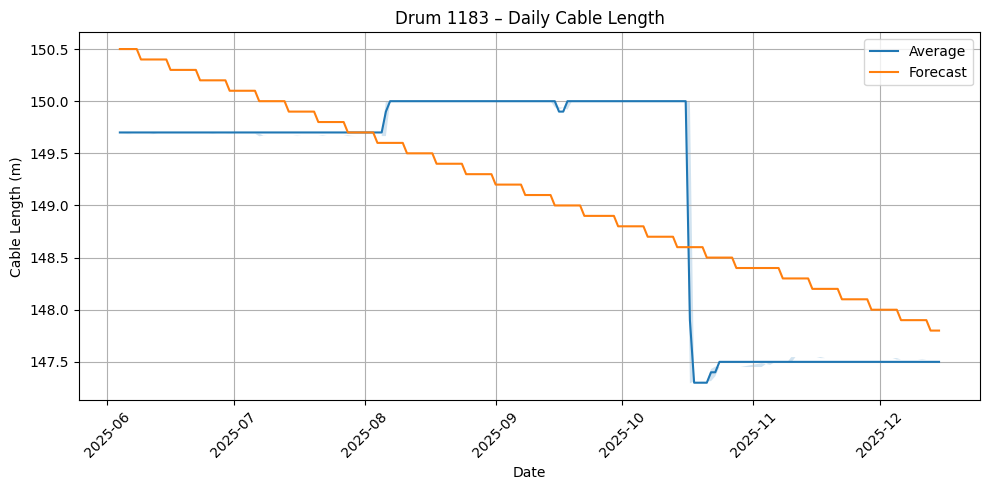

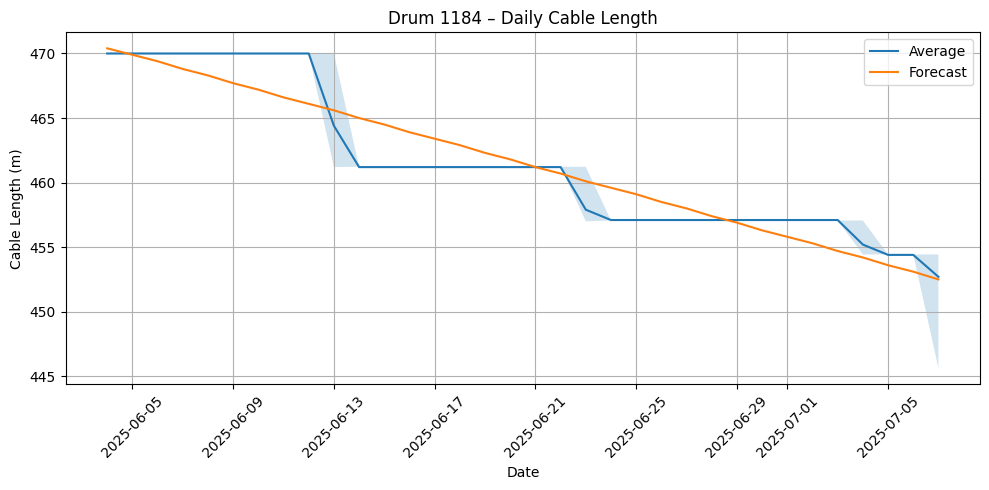

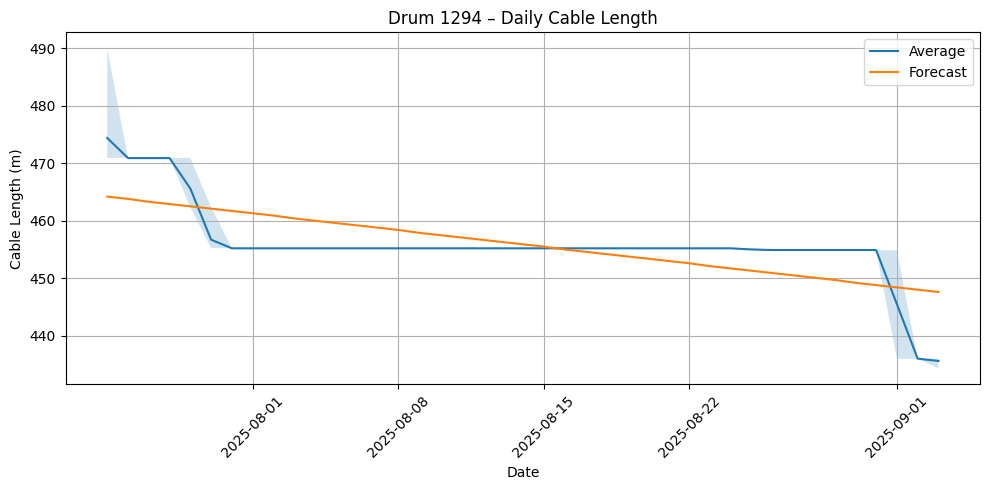

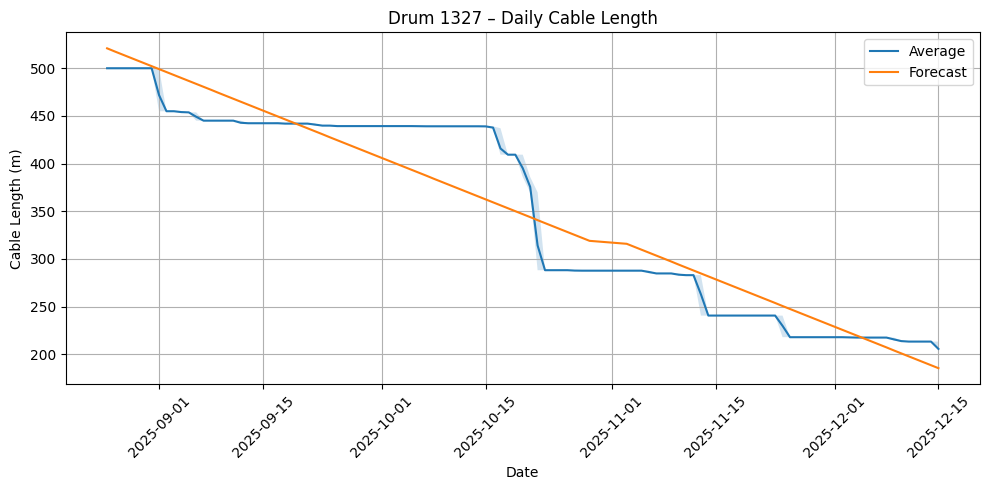

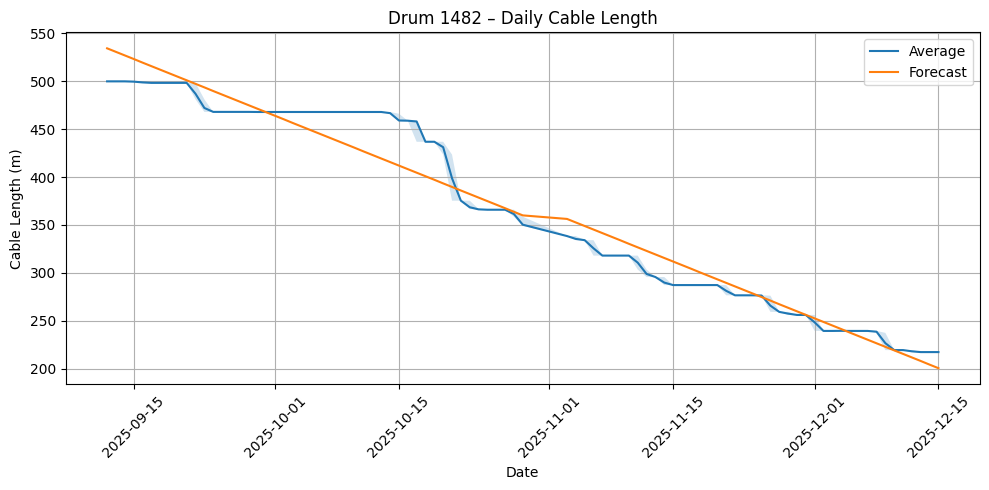

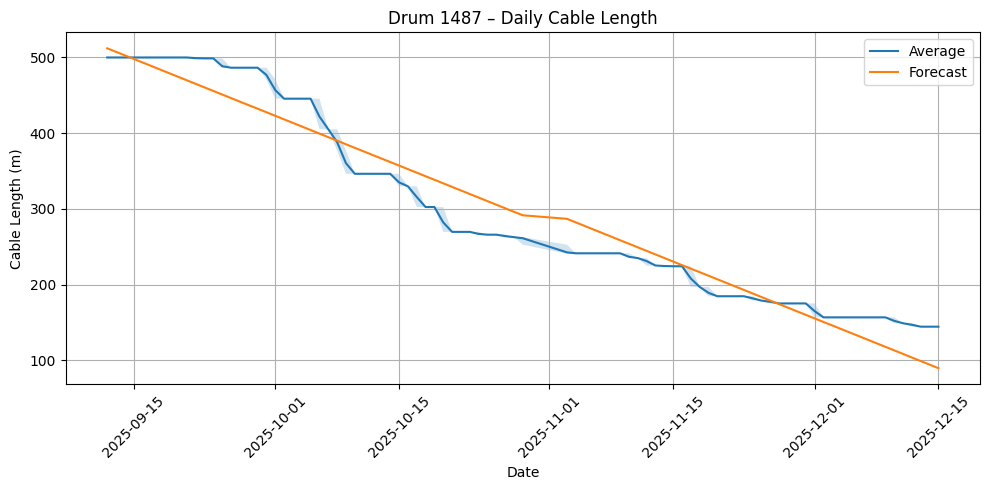

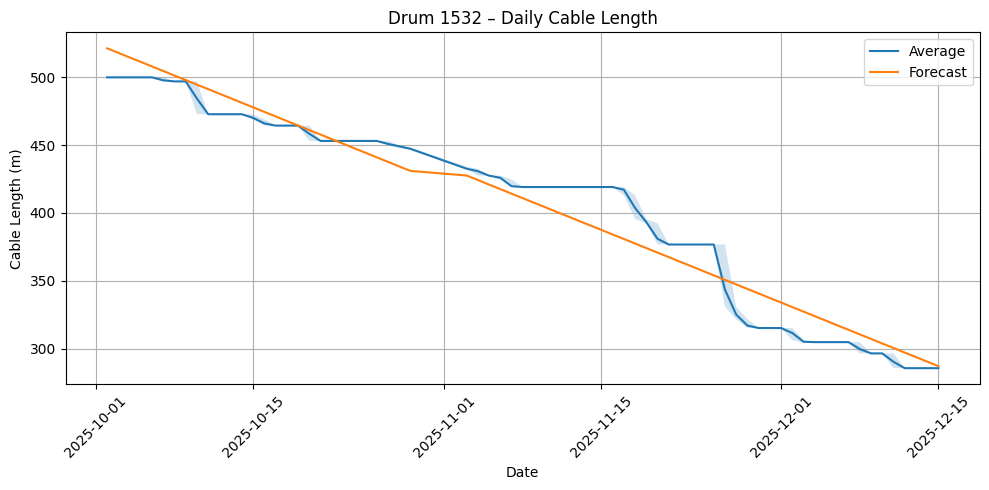

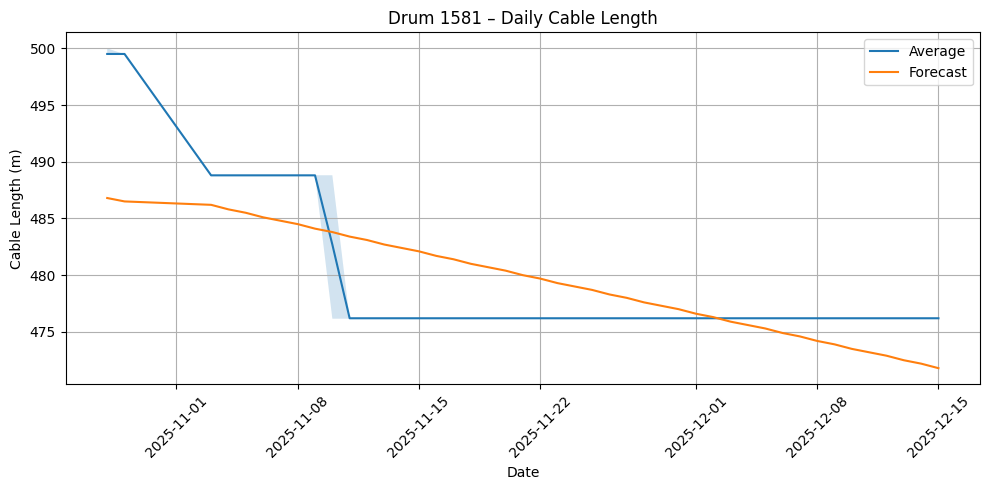

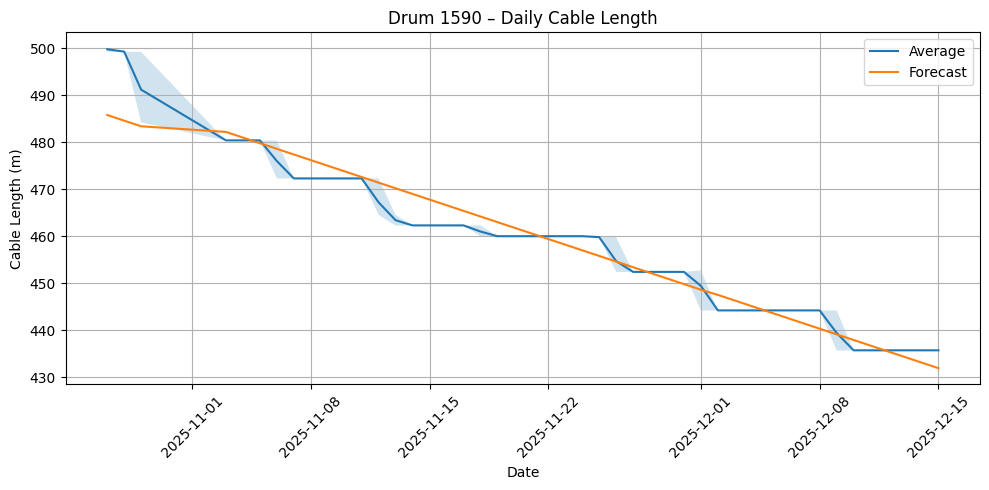

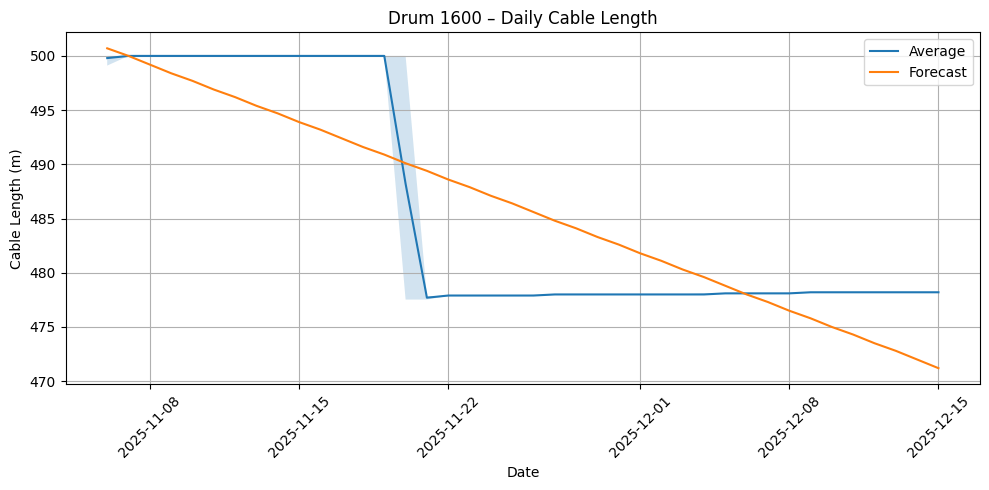

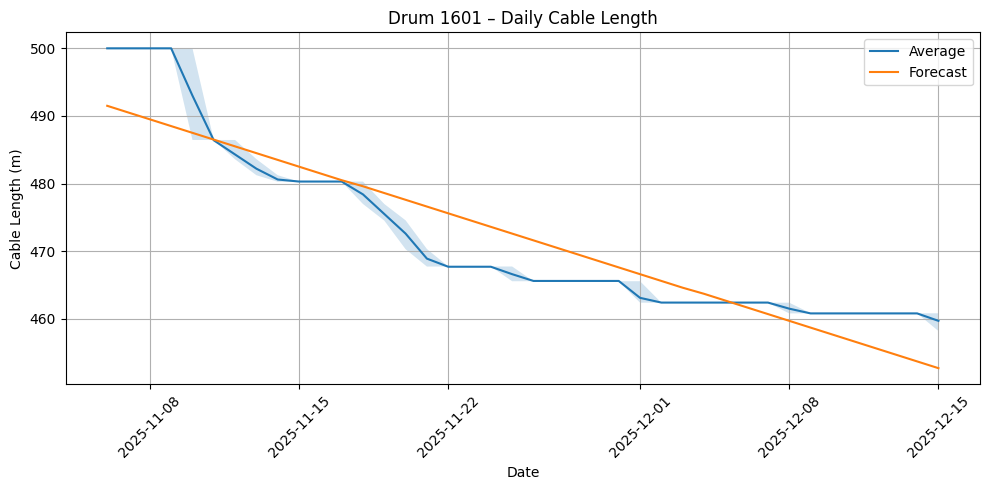

In [15]:
# Sort
rackcostumera = rackcostumera.sort_values('date')

# Loop over each drum
for drum_id, df in rackcostumera.groupby('drum_id'):
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(df['date'], df['daily_avg_cable_length_m'], label='Average')
    plt.plot(df['date'], df['linear_forecast_m'], label='Forecast')

    plt.fill_between(
        df['date'],
        df['daily_min_cable_length_m'],
        df['daily_max_cable_length_m'],
        alpha=0.2
    )

    plt.title(f'Drum {drum_id} – Daily Cable Length')
    plt.xlabel('Date')
    plt.ylabel('Cable Length (m)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

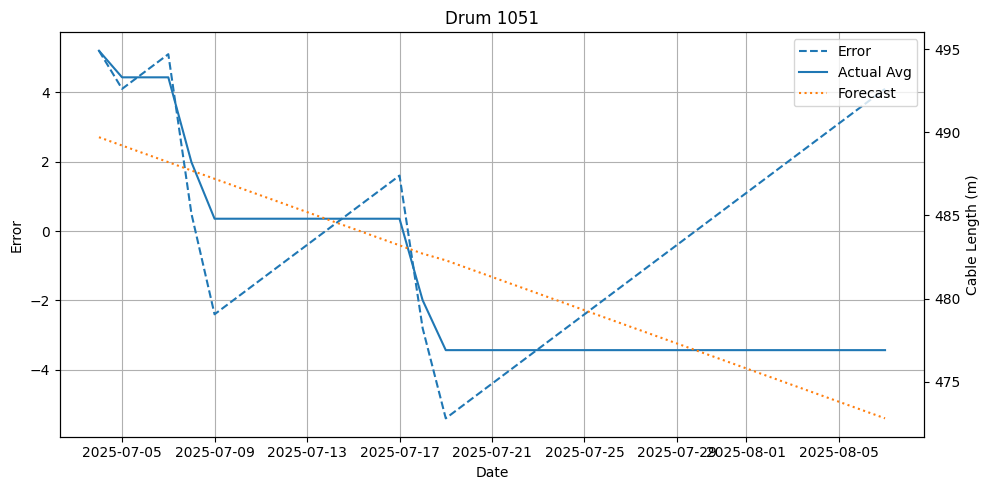

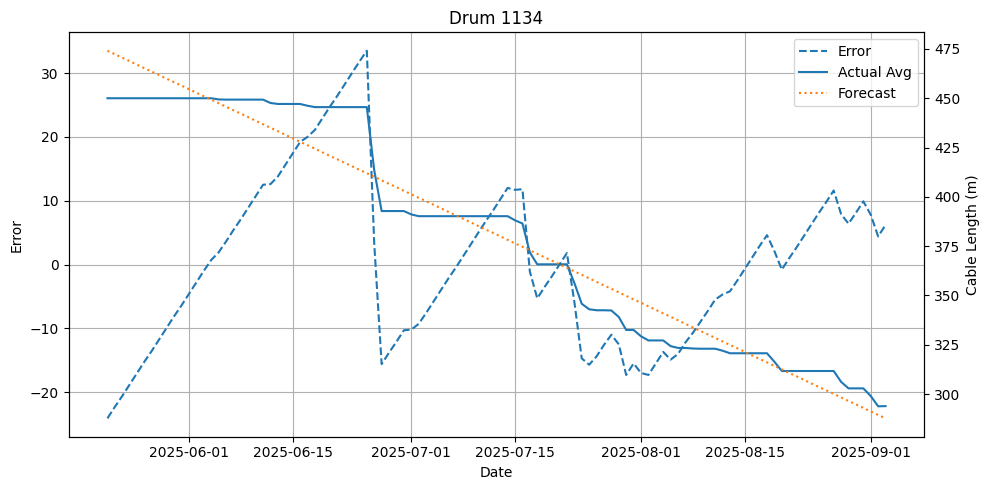

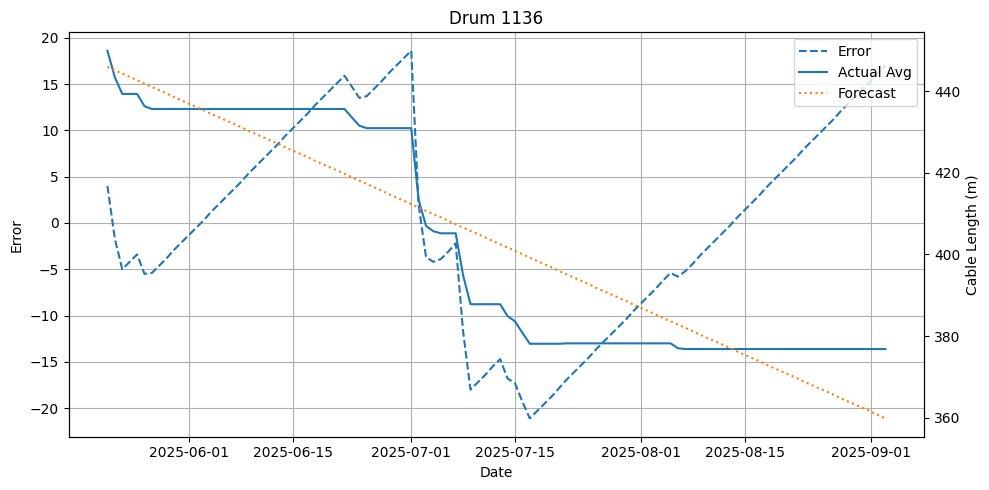

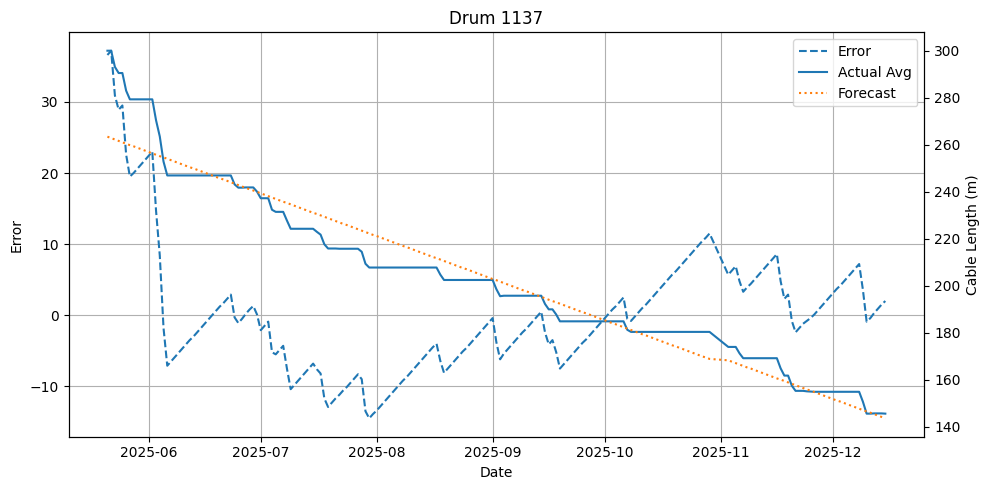

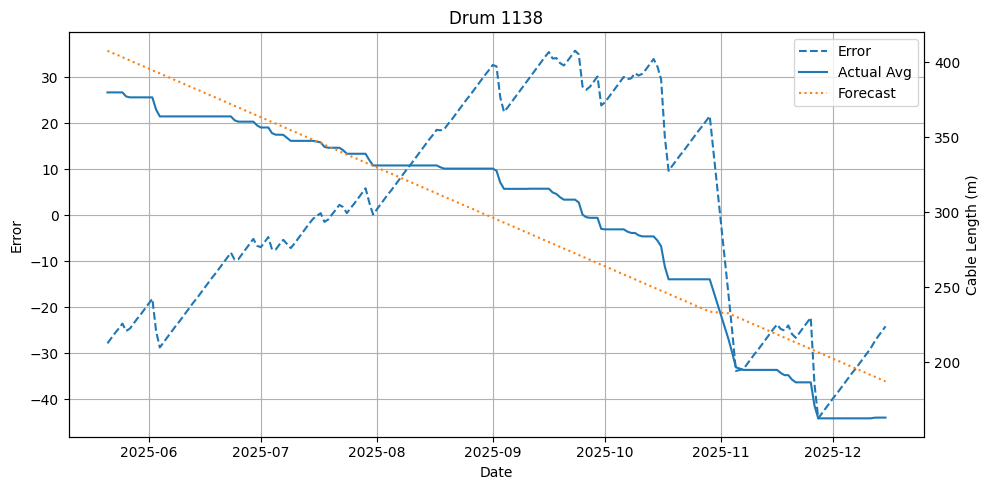

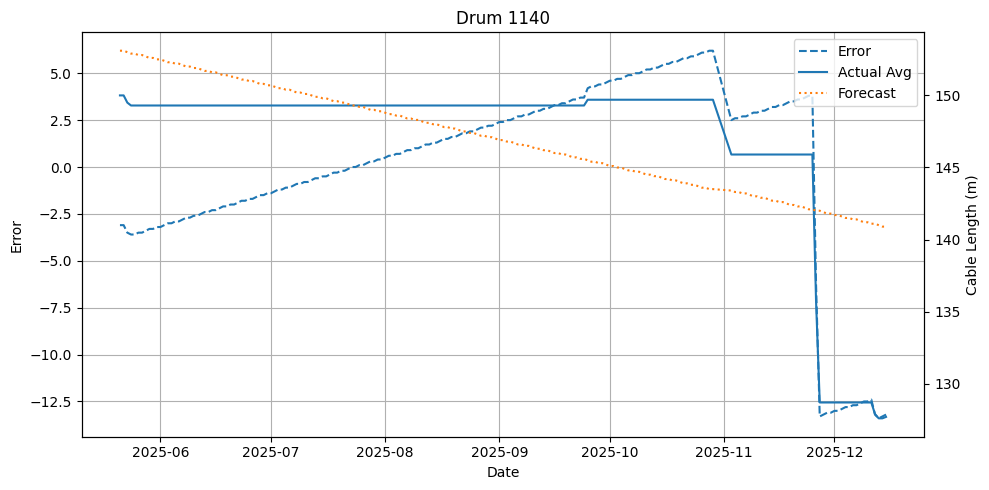

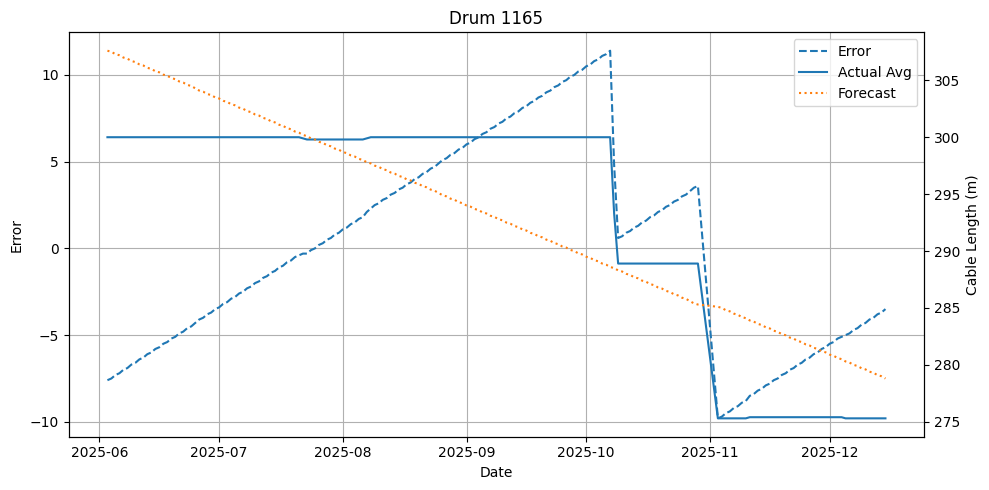

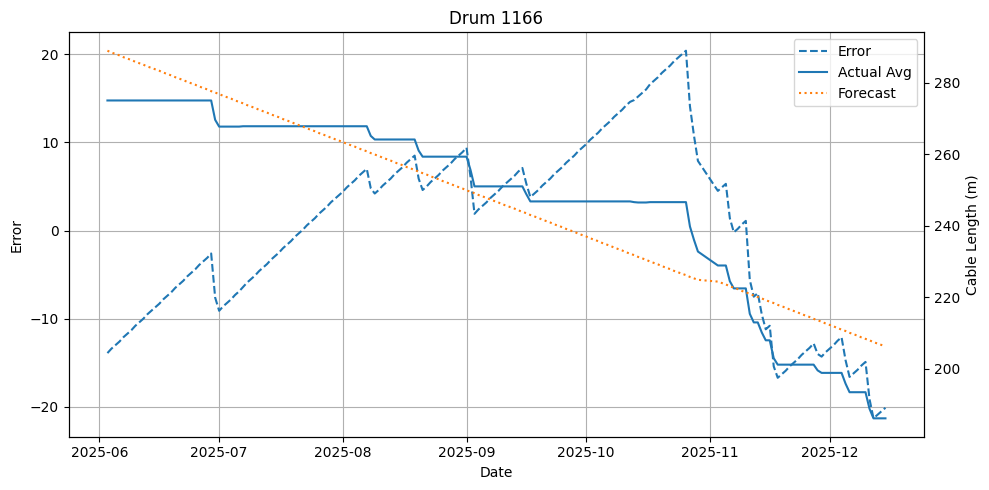

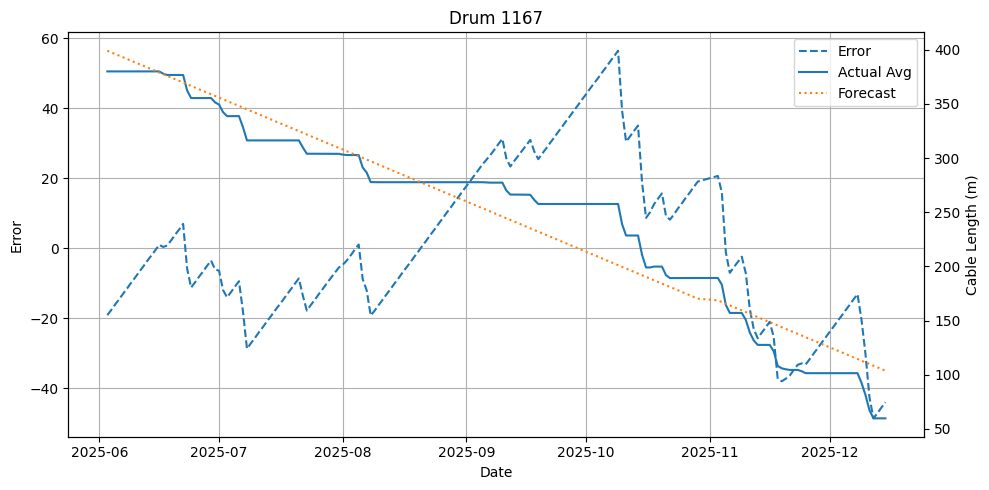

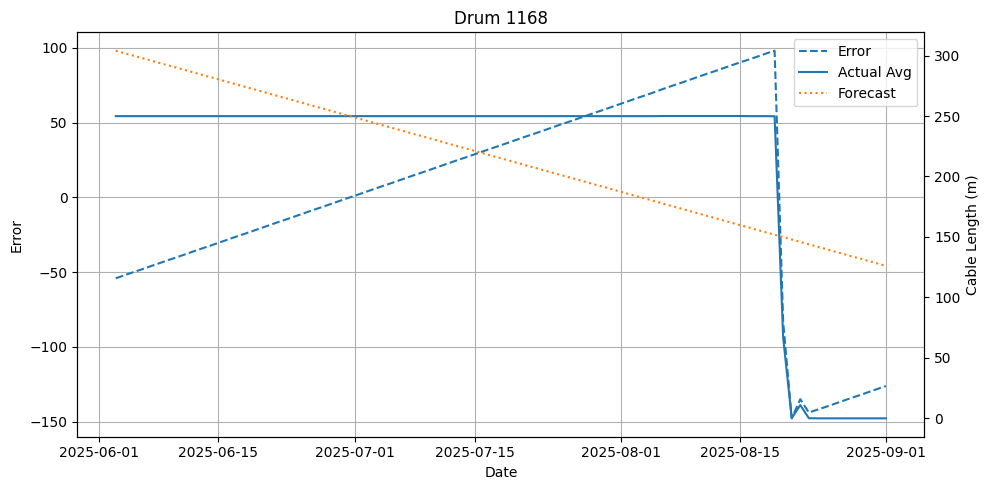

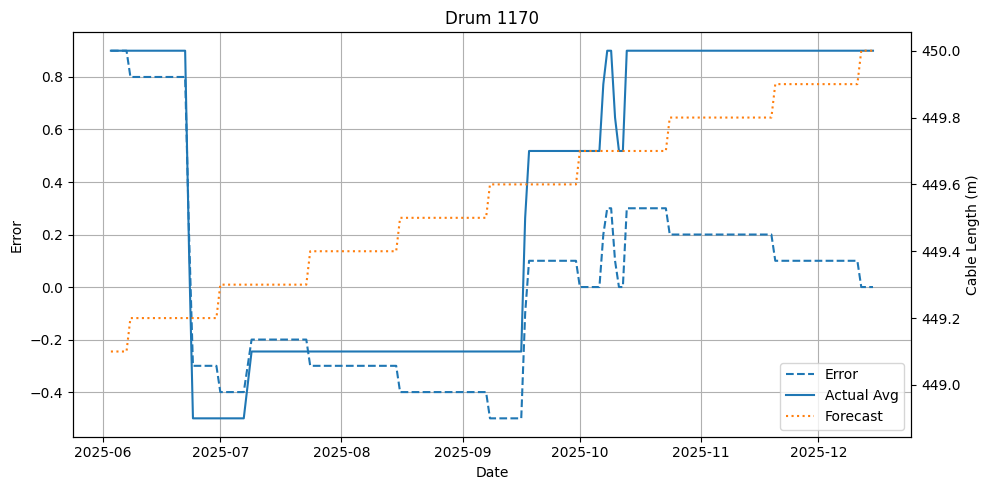

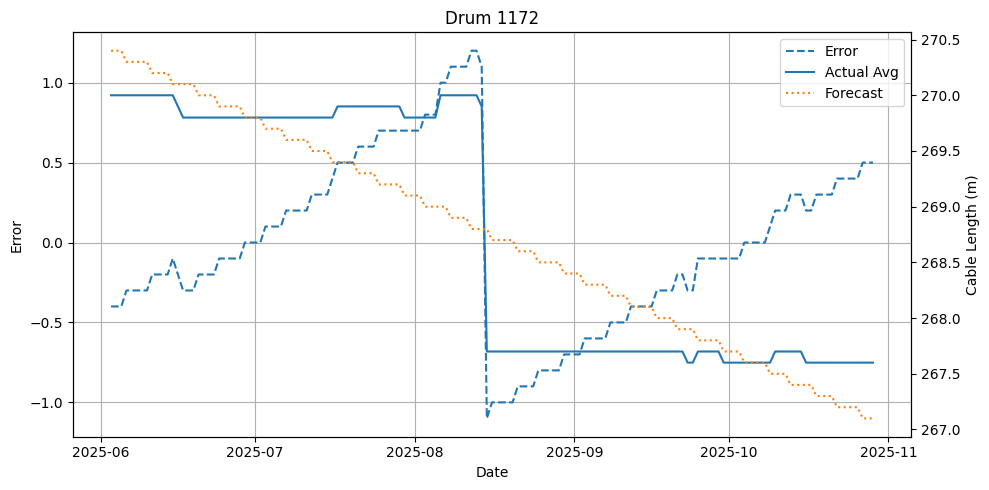

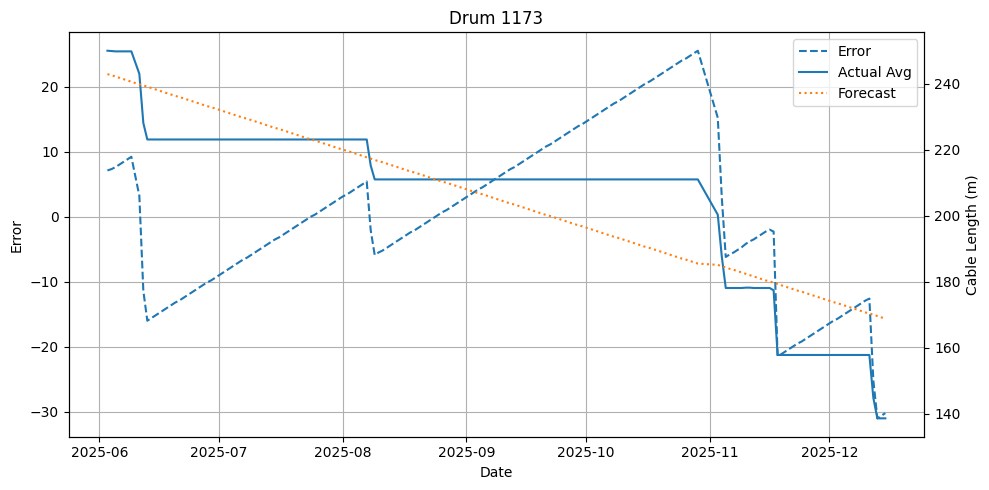

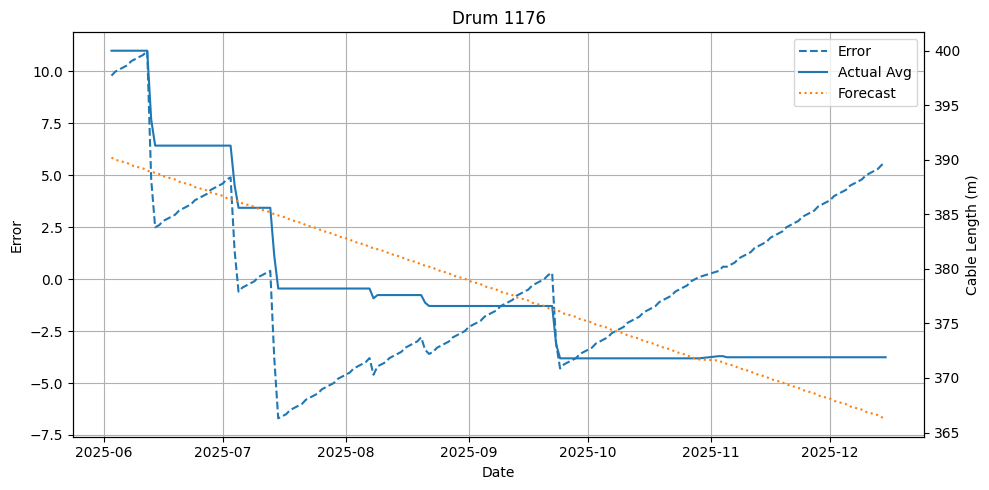

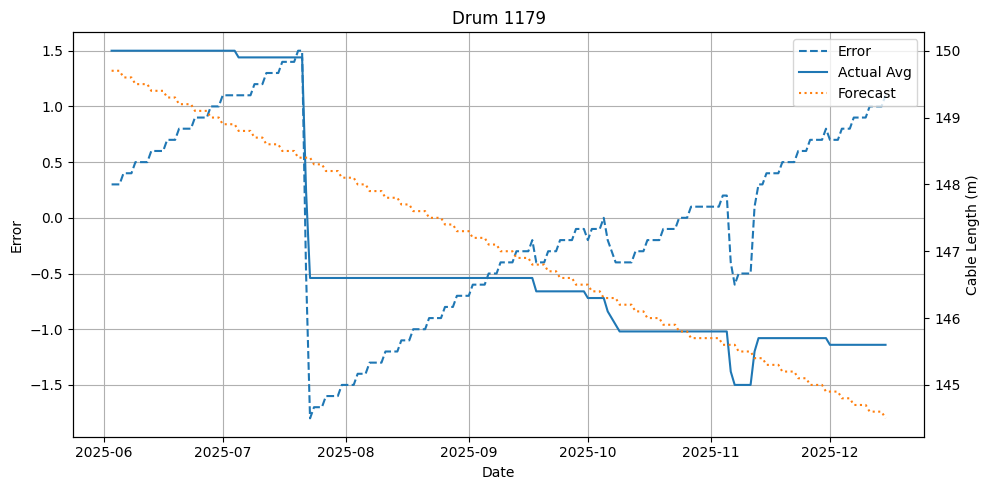

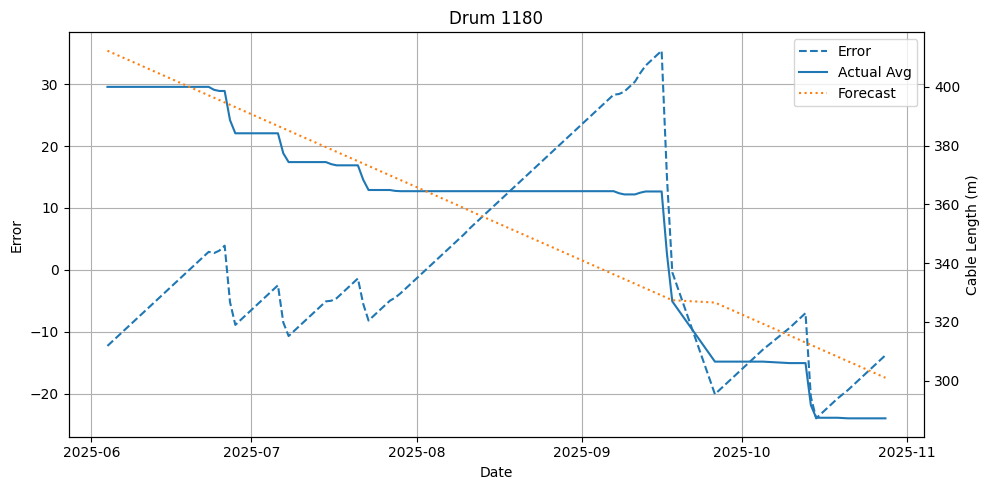

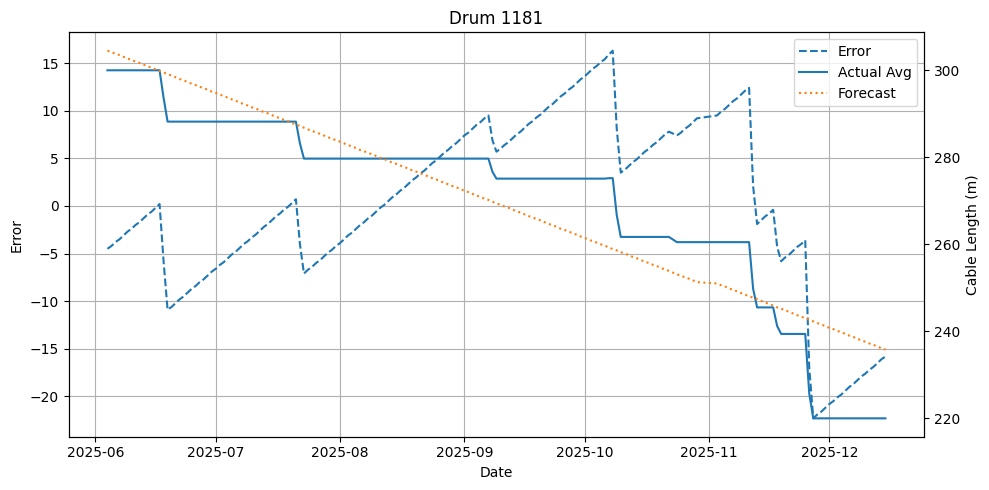

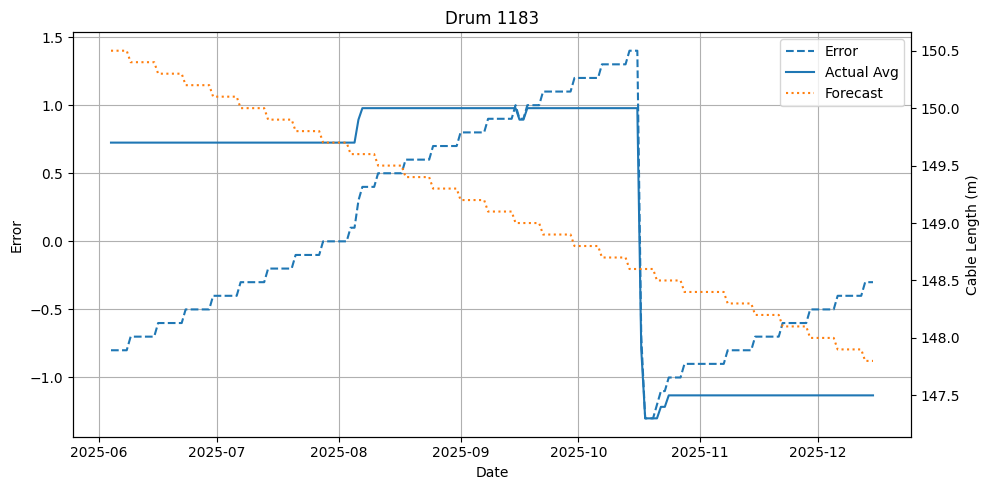

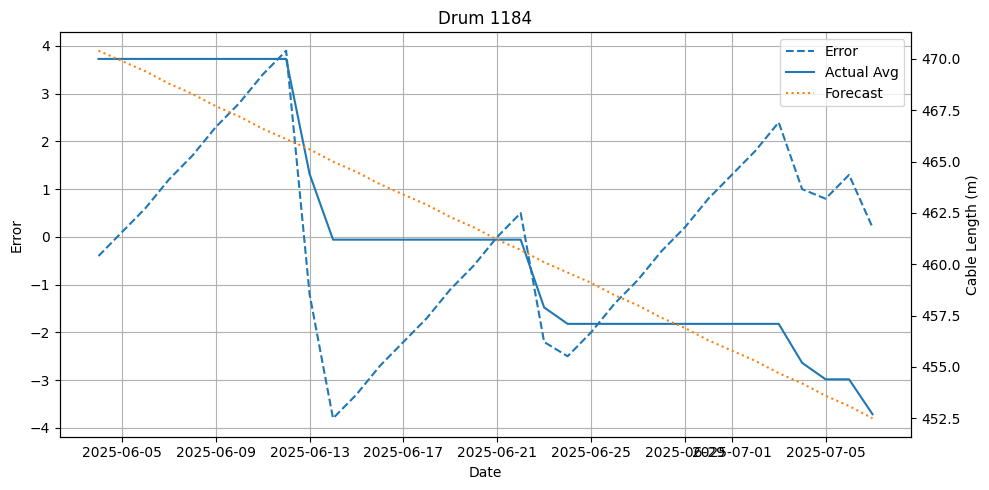

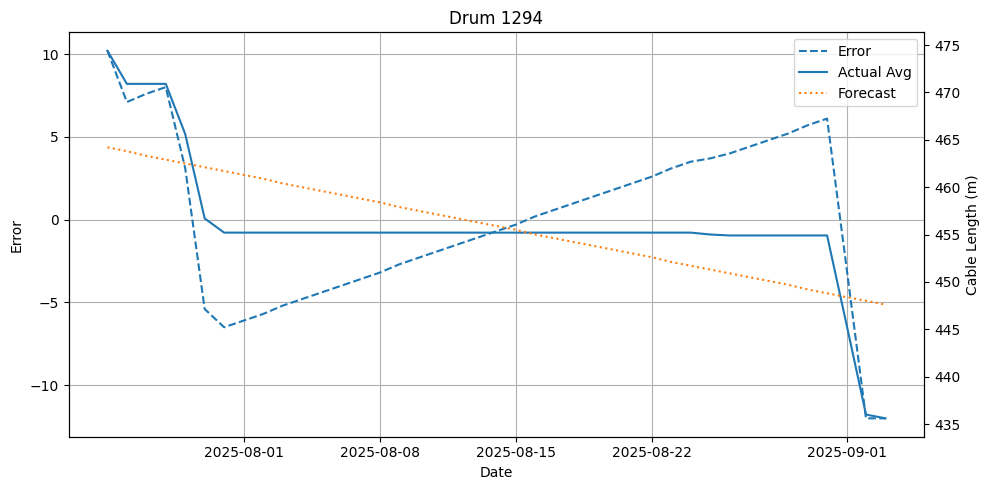

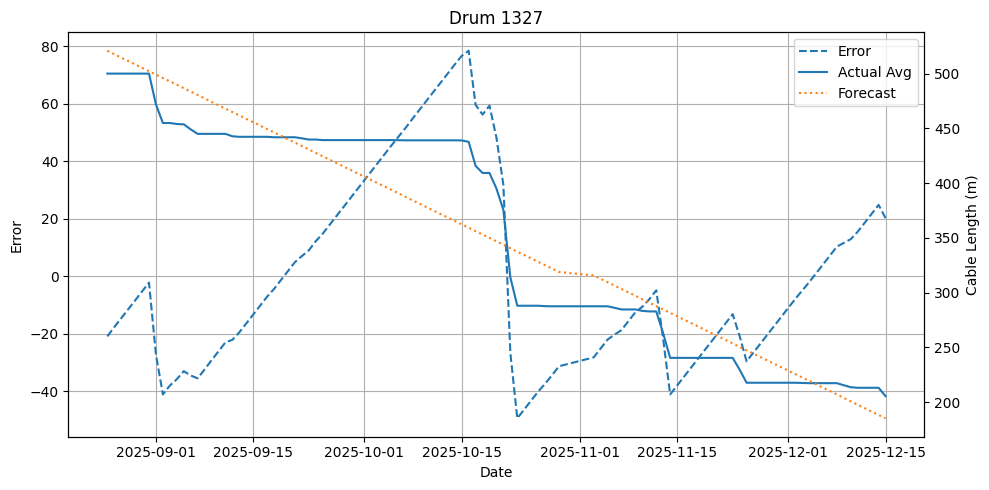

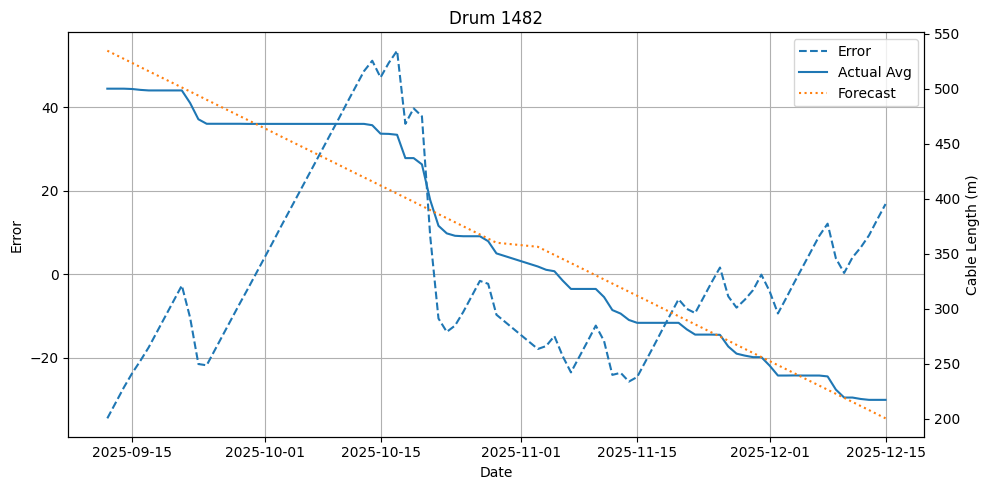

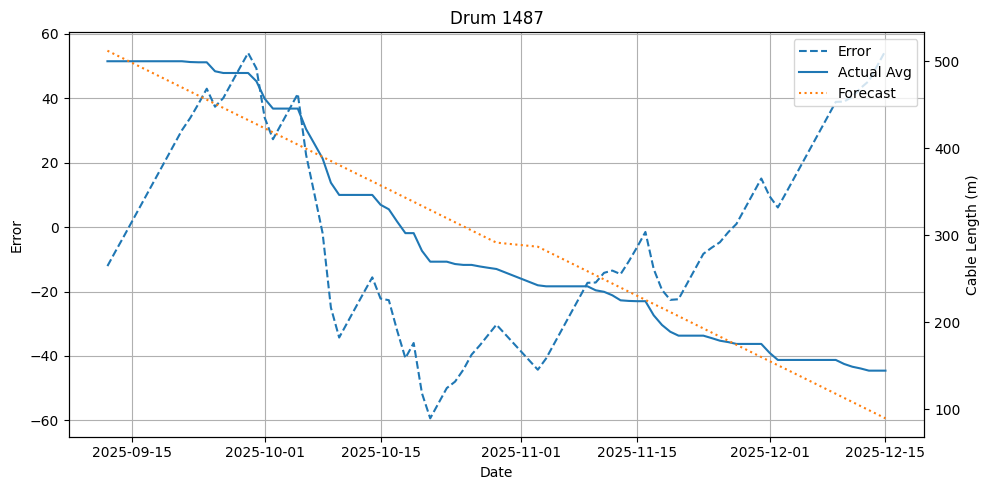

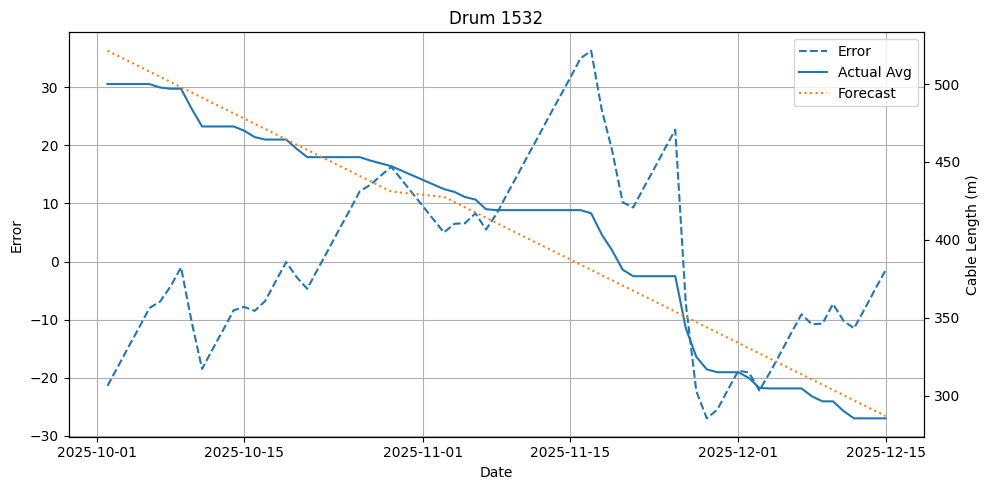

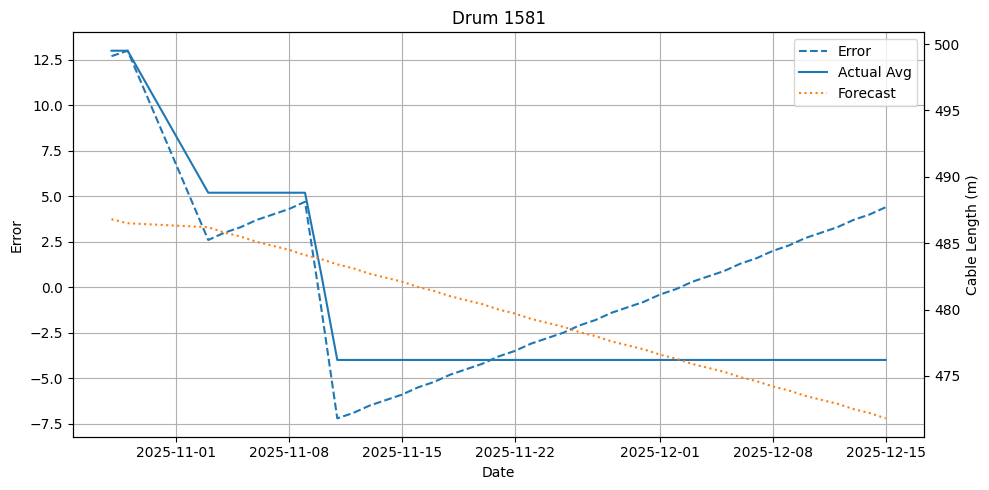

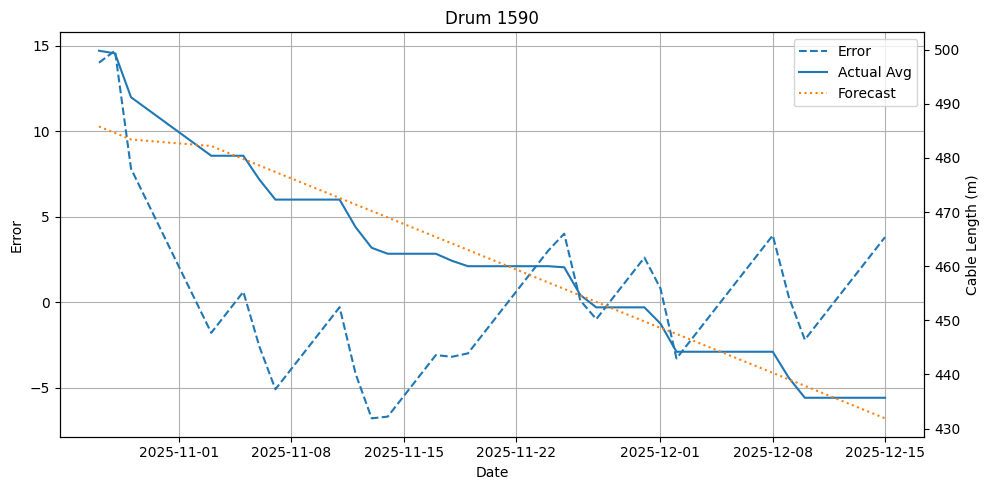

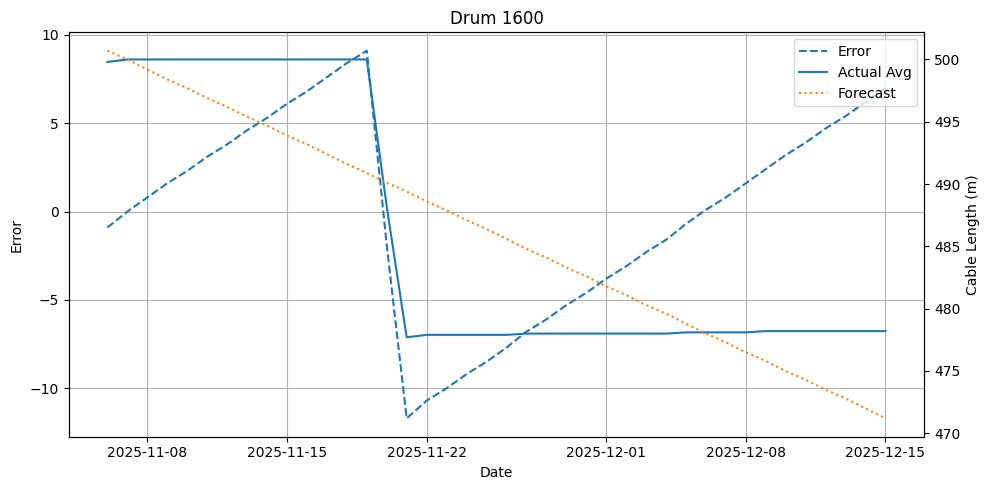

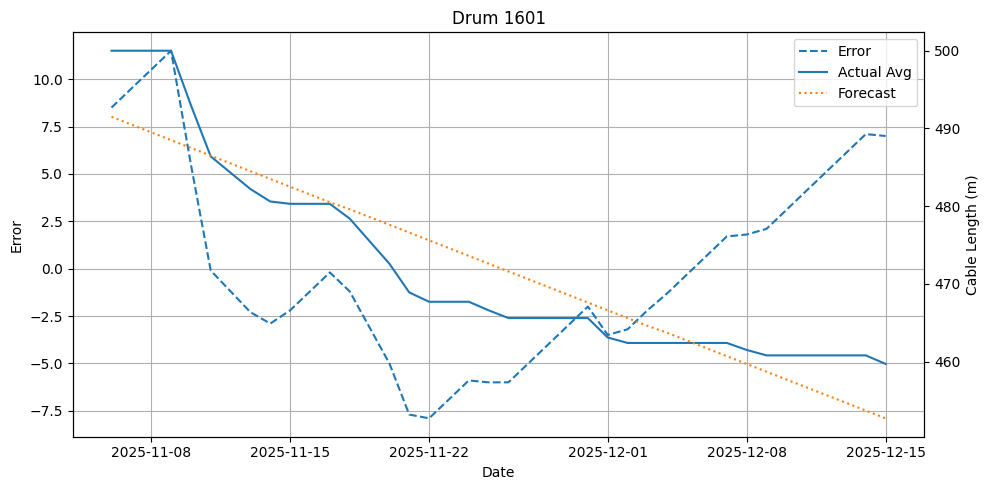

In [16]:
for drum_id, df in rackcostumera.groupby('drum_id'):
    
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Error (left)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Error')
    ax1.plot(df['date'], df['forecast_error_m'], linestyle='--', label='Error')
    ax1.grid(True)

    # Values (right)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Cable Length (m)')
    ax2.plot(df['date'], df['daily_avg_cable_length_m'], label='Actual Avg')
    ax2.plot(df['date'], df['linear_forecast_m'], linestyle=':', label='Forecast')

    # Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.title(f'Drum {drum_id}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()